In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


/tmp/ipykernel_11831/1485783505.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [5]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])


In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', StandardScaler(),
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [7]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
# ============ #
# 7. MODELO LIGHTGBM #
# ============ #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(random_state=42))
])

model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 127
[LightGBM] [Info] Number of data points in the train set: 175000, number of used features: 42
[LightGBM] [Info] Start training from score 145687.018737


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor', LGBMRegressor(random_state=42))])

In [9]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 4432.605131951134
RMSE: 5579.074571336306
MAPE: 0.032561063390679386
MAPE(%): 3.2561063390679386
R2: 0.9776643927550803


In [10]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
24423,19,19,0,DevOps Engineer,High School,Retail,Large,Singapore,Yes,164850,172760.166919,-7910.166919,7910.166919
8876,12,16,4,Cybersecurity Analyst,Bachelor,Government,Startup,UK,Hybrid,144054,151255.383154,-7201.383154,7201.383154
30673,14,1,4,Data Scientist,Bachelor,Consulting,Startup,Remote,Yes,127624,128013.602555,-389.602555,389.602555
28924,5,4,1,Software Engineer,PhD,Media,Small,Singapore,Hybrid,121864,121231.585712,632.414288,632.414288
54569,1,9,2,Backend Developer,Bachelor,Telecom,Small,Singapore,No,97224,94307.644146,2916.355854,2916.355854
59405,0,2,1,Data Scientist,High School,Education,Medium,Canada,Yes,113526,114443.193723,-917.193723,917.193723
51946,10,8,5,Business Analyst,Bachelor,Media,Startup,Netherlands,No,106903,98551.292377,8351.707623,8351.707623
17138,4,9,3,AI Engineer,High School,Education,Small,Netherlands,Hybrid,129640,123930.246734,5709.753266,5709.753266
64657,2,14,4,Cybersecurity Analyst,High School,Telecom,Startup,Remote,Hybrid,100325,100258.702844,66.297156,66.297156
49004,20,7,1,Cloud Engineer,High School,Healthcare,Startup,USA,No,169175,173865.631726,-4690.631726,4690.631726


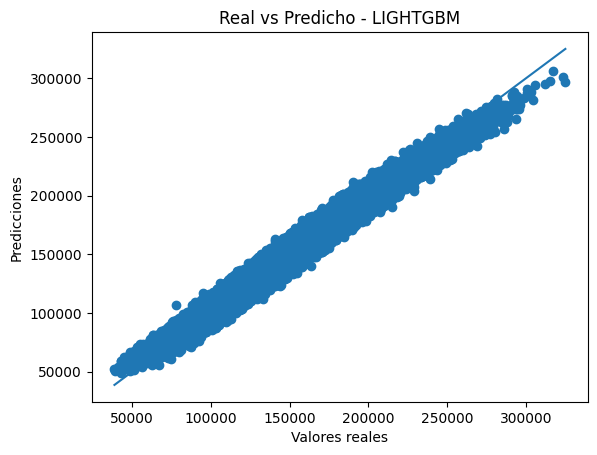

In [11]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - LIGHTGBM")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


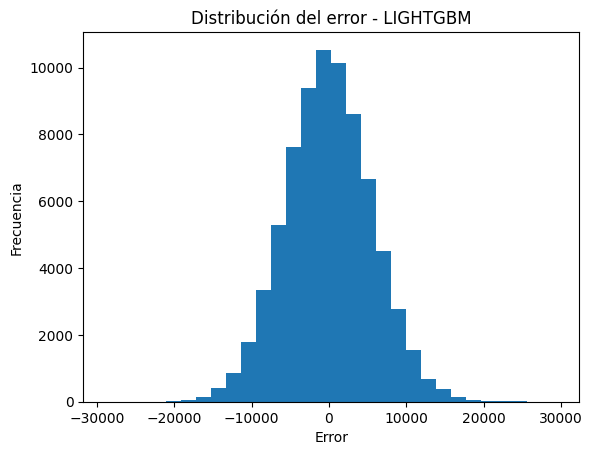

In [12]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - LIGHTGBM")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()


In [13]:
import warnings
from sklearn.model_selection import cross_validate
import numpy as np

# 1. Silenciamos advertencias de librerías y mensajes de LightGBM
warnings.filterwarnings('ignore')

# Actualizamos el modelo para que no imprima logs innecesarios
# Asegúrate de que 'model' ya esté definido antes de esta celda
if hasattr(model, 'set_params'):
    model.set_params(regressor__verbose=-1)

# 2. Definimos las métricas de evaluación
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# 3. Ejecutamos la validación cruzada (10-Fold)
# Nota: Esto puede tardar un poco dependiendo de tu PC
cv_results = cross_validate(model, X_train, y_train, cv=10, scoring=scoring)

# 4. Procesamos y formateamos los resultados
mae_scores = -cv_results['test_mae']
rmse_scores = -cv_results['test_rmse']
r2_scores = cv_results['test_r2']

# 5. Imprimimos el reporte final
print("="*40)
print("   RESULTADOS LIGHTGBM (VALIDACIÓN CRUZADA)   ")
print("="*40)
print(f"MAE  Promedio: {mae_scores.mean():.2f} (±{mae_scores.std():.2f})")
print(f"RMSE Promedio: {rmse_scores.mean():.2f} (±{rmse_scores.std():.2f})")
print(f"R²   Promedio: {r2_scores.mean():.4f} (±{r2_scores.std():.4f})")
print("="*40)

   RESULTADOS LIGHTGBM (VALIDACIÓN CRUZADA)   
MAE  Promedio: 4462.97 (±37.54)
RMSE Promedio: 5617.79 (±43.71)
R²   Promedio: 0.9775 (±0.0004)


In [14]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Definimos los parámetros a probar
param_dist_lgbm = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [31, 50, 70],
    'regressor__verbosity': [-1]
}

# 2. Búsqueda aleatoria (probaremos 5 combinaciones para que no tarde una hora)
random_search_lgbm = RandomizedSearchCV(
    model, 
    param_distributions=param_dist_lgbm, 
    n_iter=5, 
    cv=5, 
    scoring='r2', 
    random_state=42
)

random_search_lgbm.fit(X_train, y_train)

print(f"Mejor R² LightGBM: {random_search_lgbm.best_score_:.4f}")
print(f"Mejores parámetros: {random_search_lgbm.best_params_}")

Mejor R² LightGBM: 0.9677
Mejores parámetros: {'regressor__verbosity': -1, 'regressor__num_leaves': 70, 'regressor__n_estimators': 100, 'regressor__learning_rate': 0.05}


In [15]:
# 1. Parámetros a tunear
param_dist_lgbm = {
    'regressor__n_estimators': [100, 200, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [20, 31, 50],
    'regressor__verbosity': [-1]
}

# 2. Búsqueda con CV
random_lgbm = RandomizedSearchCV(
    model, 
    param_distributions=param_dist_lgbm, 
    n_iter=10, # Probará 10 combinaciones al azar
    cv=5, 
    scoring='neg_mean_absolute_error',
    random_state=42
)

random_lgbm.fit(X_train, y_train)
print(f"Mejor configuración LightGBM: {random_lgbm.best_params_}")

Mejor configuración LightGBM: {'regressor__verbosity': -1, 'regressor__num_leaves': 50, 'regressor__n_estimators': 500, 'regressor__learning_rate': 0.05}


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Predicción con el modelo original (el que estaba sin ajustar)
y_pred_base = model.predict(X_test)

# 2. Predicción con el modelo ajustado (el mejor que encontró RandomizedSearch)
# Usamos .best_estimator_ que ya tiene los parámetros optimizados
best_lgbm = random_lgbm.best_estimator_
y_pred_tuned = best_lgbm.predict(X_test)

# 3. Cálculo de métricas
mae_base = mean_absolute_error(y_test, y_pred_base)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

# 4. Reporte comparativo para el Ítem C y D
print("-" * 30)
print(" COMPARATIVA LIGHTGBM ")
print("-" * 30)
print(f"MAE Inicial:   {mae_base:.2f}")
print(f"MAE Ajustado:  {mae_tuned:.2f}")
print(f"R2 Ajustado:   {r2_tuned:.4f}")
print("-" * 30)

if mae_tuned < mae_base:
    print(f"¡Éxito! El error bajó en {mae_base - mae_tuned:.2f} unidades.")
else:
    print("El modelo base ya era óptimo o el ajuste fue muy ligero.")

------------------------------
 COMPARATIVA LIGHTGBM 
------------------------------
MAE Inicial:   4432.61
MAE Ajustado:  4140.57
R2 Ajustado:   0.9807
------------------------------
¡Éxito! El error bajó en 292.04 unidades.


In [17]:
# ==================== #
# 9. GUARDAR EL MODELO #
# ==================== #

import joblib

models_path = os.path.join(os.getcwd(), "..", "..", "models")
os.makedirs(models_path, exist_ok=True)

model_filename = os.path.join(models_path, "model_lightgbm.joblib")
joblib.dump(best_lgbm, model_filename)

print(f"Modelo guardado en: {model_filename}")

Modelo guardado en: /home/sebas/VScode/analitica-proyecto/notebooks/Modelos/../../models/model_lightgbm.joblib
